## Специфика метрик для разных типов продуктов

Тип продукта определяется его бизнес-моделью: как создаётся и монетизируется ценность. Модель однозначно диктует, какие метрики жизненно важны, а какие — шум. 

В Лекции 2 мы рассматривали фреймворки, отвечающие на вопрос «как выбирать метрику». На семинаре выясним, что этот выбор наполовину предопределен моделью.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 14, 'axes.titlesize': 17, 'axes.labelsize': 14, 'axes.titlepad': 16,
    'figure.figsize': (11, 5), 'axes.spines.top': False, 'axes.spines.right': False,
})
def legend_below(ax, ncol=3):
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=ncol, frameon=False)

rng = np.random.default_rng(7)
pd.options.display.float_format = '{:.3f}'.format

### Пять моделей: от денег — к центральной метрике

Читаем каждую модель одним и тем же способом: **откуда деньги → что из этого следует → какая метрика главная.**

#### 1) Subscription (подписки: SaaS, стриминги)
Деньги: **регулярный платеж**, выручка = база × (1 − churn)^t.   
Главная: churn / retention подписки.   
Сопутствующие: MRR, activation в привычку, expansion.

#### 2) Marketplace (двусторонние площадки)
Деньги: комиссия со сделки; сделка требует **встречи спроса и предложения**. Обе стороны могут расти, а сделки — падать: не там, не тогда, не по той цене.
Главная: ликвидность — вероятность, что запрос закроется за приемлемое время.   
Сопутствующие: баланс сторон supply/demand, GMV, take rate.

#### 3) E-commerce
Деньги: маржа с заказа; экономика решается тем, **вернется ли покупатель** — окупается CAC одной покупкой или потоком.   
Главная: повторная покупка / выручка.    
Сопутствующие: AOV, частота, конверсия.

#### 4) UGC (контентные платформы, соцсети)
Деньги: внимание → реклама. Основная ценность в платформе — контент, а создают его пользователи: **лестница 90–9–1** (потребляют / взаимодействуют / создают).   
Главная: доля и удержание создающих (content creation rate).    
Сопутствующие: engagement, time spent, DAU/MAU.

#### 5) Mobile F2P (игры, freemium)
Деньги: малая доля платящих при массовой бесплатной базе; выручка сконцентрирована в «китах».   
Главная: stickiness (DAU/MAU) × конверсия в платящих.   
Сопутствующие: ARPPU, retention D1/D7/D30, длина сессии.


*Croll & Yoskovitz — Lean Analytics: Use Data to Build a Better Startup Faster (2013)*

### Режимы e-commerce: одна модель — три разные компании

Croll & Yoskovitz делят e-com по **доле покупателей, возвращающихся за повторной покупкой в 90 дней**:

| Режим | Повторная покупка за 90д | Что это значит | Куда идут деньги и фокус |
|---|---|---|---|
| **Acquisition** | ≲ 15% | покупка разовая или редкая (шины, матрасы) | привлечение: CAC, конверсия, AOV — выжать максимум из единственной покупки |
| **Hybrid** | 15–30% | смешанный спрос (электроника с аксессуарами, товары для дома, одежда и обувь)| баланс: и воронка, и лояльность |
| **Loyalty** | ≳ 30% | продукт регулярной корзины (еда, косметика, FMCG) | удержание: частота, retention, подписочные механики |

Допустимый CAC для разных моделей будет отличаться в несколько раз — в loyalty-режиме покупатель приносит поток покупок, в acquisition — одну. Понимание частотности потребления оказывает прямое влияние на то, как мы будем трактовать значения метрик. 

**Норма метрики не существует вне типа продукта.**

### 🔎 Пример: распознаем типы продукта по их продуктовым метрикам

Перед нами логи четырех безымянных продуктов — A, B, C, D. Где-то среди них: подписочный сервис, mobile-F2P игра, e-commerce и маркетплейс.

Ход решения: 
1) Считаем универсальный диагностический набор;
2) По профилю значений опознаем каждую модель;
3) Для e-com-кандидата определяем режим.

Схема логов: `user_id`, `ts`, `event_type` (activity / payment / listing), `amount` (для payment), `role` (для части продуктов).

In [2]:
def generate_products(seed=11):
    rng = np.random.default_rng(seed)
    t0, days = pd.Timestamp('2026-06-01'), 100
    out = {}

    def stamp(n, active_days_per_user):
        d = rng.integers(0, days, n); s = rng.uniform(8*3600, 23*3600, n)
        return t0 + pd.to_timedelta(d*86400 + s, unit='s')

    n = 6000
    rows = []
    for u in range(n):
        uid = f'A_{u:05d}'
        paid = rng.random() < 0.7                           
        life = min(days, int(rng.exponential(650 if paid else 45)))
        for d in range(0, life, 1):
            if rng.random() < (0.45 if paid else 0.3):
                rows.append((uid, t0 + pd.Timedelta(days=d, hours=int(rng.uniform(8, 23))), 'activity', np.nan, 'user'))
        if paid:
            for m in range(0, max(1, life // 30) + 1):
                if m * 30 < life:
                    rows.append((uid, t0 + pd.Timedelta(days=m*30, hours=12), 'payment', 9.99, 'user'))
    out['A'] = rows

    n = 9000
    rows = []
    for u in range(n):
        uid = f'B_{u:05d}'
        life = min(days, int(rng.exponential(60)))
        for d in range(life):
            if rng.random() < 0.42:                
                rows.append((uid, t0 + pd.Timedelta(days=d, hours=int(rng.uniform(7, 24))), 'activity', np.nan, 'user'))
        if rng.random() < 0.025:                              
            whale = rng.lognormal(0, 1.15)                   
            for _ in range(rng.poisson(2 + 3 * min(whale, 8)) + 1):
                amt = float(np.round(rng.choice([0.99, 4.99, 9.99, 49.99, 99.99],
                                                p=[.45,.3,.15,.07,.03]) * max(1, whale/2), 2))
                rows.append((uid, stamp(1, None)[0], 'payment', amt, 'user'))
    out['B'] = rows

    n = 7000
    rows = []
    for u in range(n):
        uid = f'C_{u:05d}'
        buyer = rng.random() < 0.65                          
        for _ in range(rng.poisson(6 if buyer else 3)):
            rows.append((uid, stamp(1, None)[0], 'activity', np.nan, 'user'))
        if buyer:
            n_orders = 1 if rng.random() < 0.25 else rng.poisson(6) + 1
            d = rng.integers(0, 20)
            for _ in range(n_orders):
                if d >= days: break
                amt = float(np.round(rng.lognormal(np.log(28), 0.5), 2))
                ts = t0 + pd.Timedelta(days=int(d), hours=int(rng.uniform(9, 22)))
                for _back in range(rng.integers(1, 3)):      
                    rows.append((uid, ts - pd.Timedelta(hours=float(rng.uniform(2, 30))), 'activity', np.nan, 'user'))
                rows.append((uid, ts, 'activity', np.nan, 'user'))  
                rows.append((uid, ts + pd.Timedelta(minutes=20), 'payment', amt, 'user'))
                d += max(1, int(rng.normal(9, 4)))     
    out['C'] = rows

    rows = []
    for u in range(5000):                                     
        uid = f'D_b{u:05d}'
        buys = rng.random() < 0.4                            
        for _ in range(rng.poisson(9 if buys else 5)):       
            rows.append((uid, stamp(1, None)[0], 'activity', np.nan, 'buyer'))
        if buys:
            n_buys = 1 + (rng.poisson(0.8) if rng.random() < 0.35 else 0)
            d = rng.integers(0, 60)
            for _ in range(n_buys):
                if d >= days: break
                amt = float(np.round(rng.lognormal(np.log(65), 0.8), 2))
                ts = t0 + pd.Timedelta(days=int(d), hours=int(rng.uniform(9, 22)))
                rows.append((uid, ts, 'activity', np.nan, 'buyer'))
                rows.append((uid, ts + pd.Timedelta(minutes=30), 'payment', amt, 'buyer'))
                d += max(10, int(rng.normal(45, 15)))            
    for u in range(1500):                                    
        uid = f'D_s{u:05d}'
        for _ in range(rng.poisson(3) + 1):
            ts_l = stamp(1, None)[0]
            rows.append((uid, ts_l, 'listing', np.nan, 'seller'))
            if rng.random() < 0.55:                           
                delay = float(rng.exponential(4) + 0.2)       
                rows.append((uid, ts_l + pd.Timedelta(days=delay), 'listing_closed', np.nan, 'seller'))
    out['D'] = rows

    cols = ['user_id', 'ts', 'event_type', 'amount', 'role']
    
    return {k: pd.DataFrame(v, columns=cols).sort_values(['user_id', 'ts']).reset_index(drop=True)
            for k, v in out.items()}

In [3]:
logs = generate_products()

for k, df in logs.items():
    print(f'Продукт {k}: {len(df):>7,} событий, {df.user_id.nunique():>6,} пользователей, '
          f'типы событий: {sorted(df.event_type.unique())}')

Продукт A: 212,446 событий,  5,876 пользователей, типы событий: ['activity', 'payment']
Продукт B: 181,889 событий,  8,656 пользователей, типы событий: ['activity', 'payment']
Продукт C: 121,256 событий,  6,882 пользователей, типы событий: ['activity', 'payment']
Продукт D:  46,640 событий,  6,478 пользователей, типы событий: ['activity', 'listing', 'listing_closed', 'payment']


#### Задание 1. Универсальный диагностический набор

Для каждого продукта посчитайте:
- **MAU** последнего полного месяца и **stickiness** (средний DAU / MAU за него)
- **payer_share** — доля пользователей с хотя бы одним платежом
- **repurchase_90d** — доля плативших, у кого ≥2 платежа за первые 90 дней жизни
- **median_gap** — медианные дни между платежами пользователя
- **ARPU** за период и **top10_rev** — доля выручки от топ-10% платящих
- Бонус-улики: `std(amount)` и состав `role`

In [4]:
print(f"period: {logs['A'].ts.max() - logs['A'].ts.min()},\nstart: {logs['A'].ts.min()},\nend: {logs['A'].ts.max()}")

period: 99 days 14:00:00,
start: 2026-06-01 08:00:00,
end: 2026-09-08 22:00:00


In [5]:
def diagnose(df):
    
    pay = df[df.event_type == 'payment']
    act = df[df.event_type.isin(['activity', 'payment'])]
    
    last_m = act[(act.ts >= '2026-08-01') & (act.ts < '2026-09-01')]
    
    mau = last_m.user_id.nunique()
    dau = last_m.assign(d=lambda x: x.ts.dt.date).groupby('d').user_id.nunique().mean()
    
    per_user = pay.groupby('user_id').agg(n=('amount', 'size'), first=('ts', 'min'))
    rep = pay.merge(per_user['first'], on='user_id')
    rep90 = rep[rep.ts <= rep['first'] + pd.Timedelta(days=90)].groupby('user_id').size()
    
    gaps = pay.sort_values('ts').groupby('user_id')['ts'].diff().dt.days.dropna()
    
    rev_u = pay.groupby('user_id')['amount'].sum().sort_values(ascending=False)
    top10 = rev_u.head(max(1, len(rev_u)//10)).sum() / rev_u.sum()
    
    return pd.Series({
        'MAU': mau, 'stickiness': dau / mau, 'payer_share': pay.user_id.nunique() / df.user_id.nunique(),
        'repurchase_90d': (rep90 >= 2).mean(), 'median_gap_days': gaps.median(),
        'ARPU': pay.amount.sum() / df.user_id.nunique(), 'top10_rev_share': top10,
        'std_amount': pay.amount.std(), 'roles': ' / '.join(sorted(df.role.unique())),
    })

In [6]:
profile = pd.DataFrame({k: diagnose(df) for k, df in logs.items()}).T
profile

,MAU,stickiness,payer_share,repurchase_90d,median_gap_days,ARPU,top10_rev_share,std_amount,roles
A,4241,0.437,0.723,0.947,30.000,26.777,0.108,0.000,user
B,3168,0.330,0.028,0.975,5.000,6.553,0.672,100.958,user
C,5610,0.094,0.664,0.754,8.000,114.399,0.212,17.179,user
D,4231,0.076,0.302,0.164,42.000,31.182,0.310,80.684,buyer / seller


#### Задание 2. Опознание моделей



- A — подписочный сервис
- B — mobile-F2P игра
- C — e-commerce
- D — маркетплейс

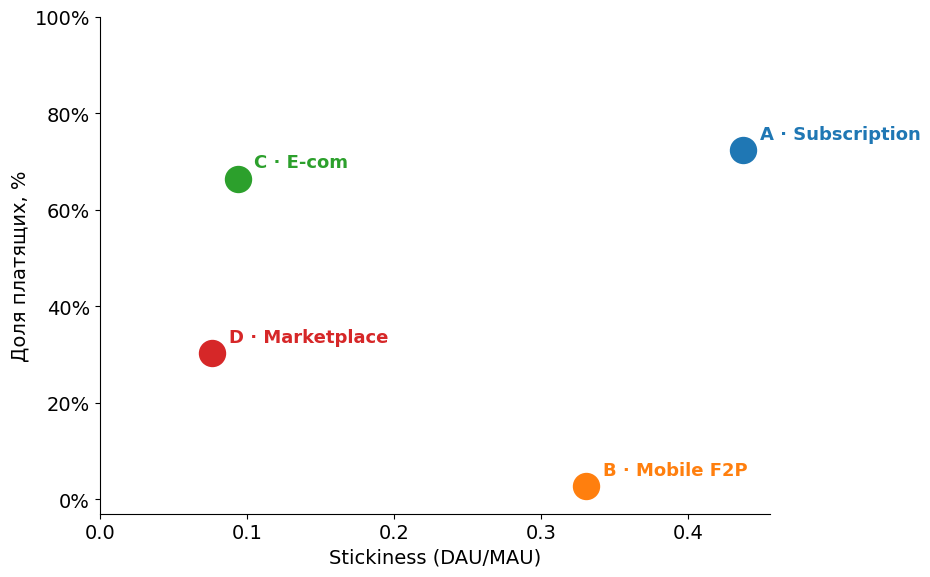

In [7]:
fig, ax = plt.subplots(figsize=(9.5, 6))
names = {'A': 'Subscription', 'B': 'Mobile F2P', 'C': 'E-com', 'D': 'Marketplace'}
colors = {'A': '#1f77b4', 'B': '#ff7f0e', 'C': '#2ca02c', 'D': '#d62728'}

for k in profile.index:
    ax.scatter(profile.loc[k, 'stickiness'], profile.loc[k, 'payer_share'],
               s=350, color=colors[k], zorder=3)
    ax.annotate(f'{k} · {names[k]}', (profile.loc[k, 'stickiness'], profile.loc[k, 'payer_share']),
                xytext=(12, 8), textcoords='offset points', fontsize=13, color=colors[k], fontweight='bold')

ax.set_xlabel('Stickiness (DAU/MAU)')
ax.set_ylabel('Доля платящих, %')
ax.set_xlim(0, None)
ax.set_ylim(-0.03, 1.0)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
plt.tight_layout()
plt.show()

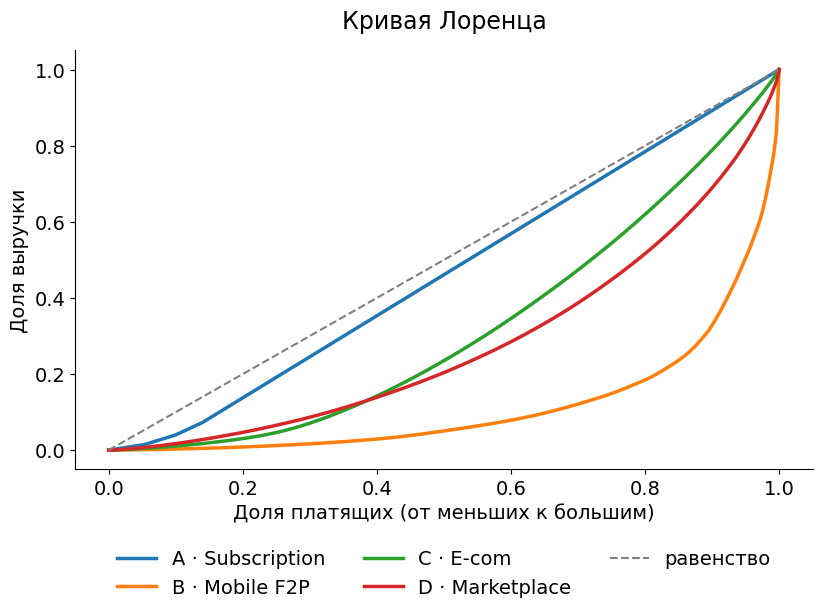

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 6.5))

for k in ['A', 'B', 'C', 'D']:
    rev = logs[k].loc[logs[k].event_type == 'payment'].groupby('user_id')['amount'].sum().sort_values()
    x = np.linspace(0, 1, len(rev)); y = rev.cumsum() / rev.sum()
    ax.plot(x, y, lw=2.5, color=colors[k], label=f'{k} · {names[k]}')

ax.plot([0, 1], [0, 1], ls='--', color='grey', lw=1.5, label='равенство')
ax.set_xlabel('Доля платящих (от меньших к большим)'); ax.set_ylabel('Доля выручки')
ax.set_title('Кривая Лоренца')

legend_below(ax, ncol=3)
plt.tight_layout()
plt.show()

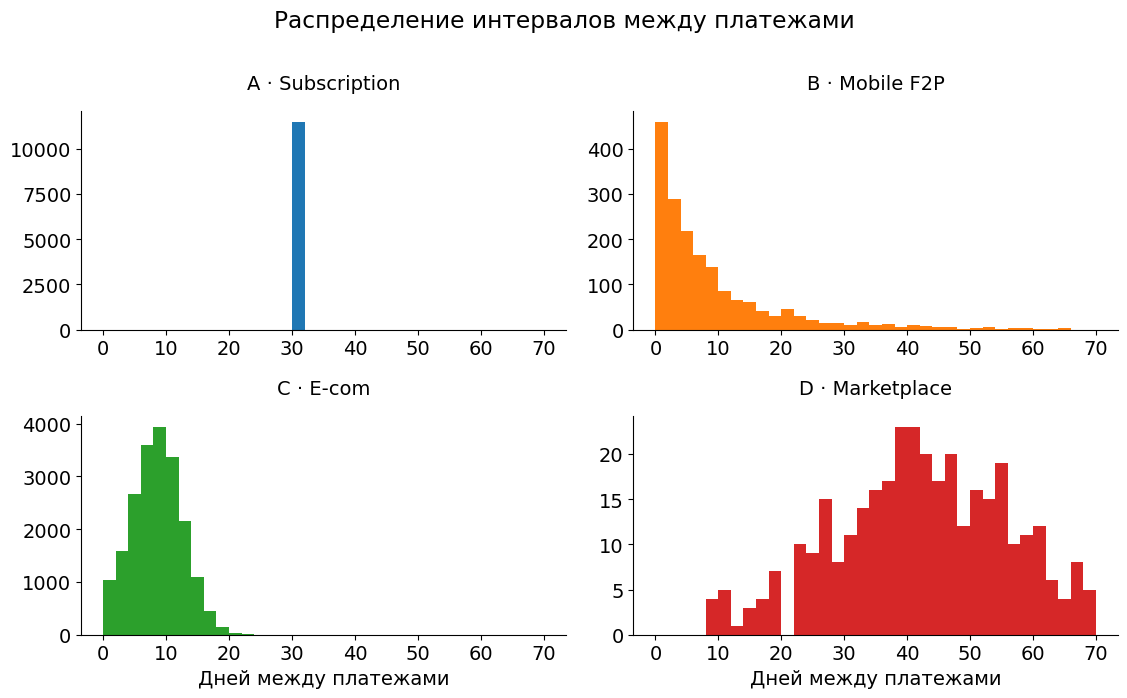

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11.5, 7), sharex=False)

for ax, k in zip(axes.ravel(), ['A', 'B', 'C', 'D']):
    g = logs[k][logs[k].event_type == 'payment'].sort_values('ts') \
            .groupby('user_id')['ts'].diff().dt.days.dropna()
    ax.hist(g, bins=np.arange(0, 71, 2), color=colors[k])
    ax.set_title(f'{k} · {names[k]}', fontsize=14)
    if k in ('C', 'D'): ax.set_xlabel('Дней между платежами')

plt.suptitle('Распределение интервалов между платежами', y=1.0)
plt.tight_layout(); plt.show()

#### Задание 3. Режим e-com

Для опознанного e-commerce определите режим (acquisition / hybrid / loyalty) по доле повторных покупателей за 90 дней — и сформулируйте одним предложением, куда этому продукту направлять деньги.

In [14]:
rep90 = profile.loc['C', 'repurchase_90d']

print(f'Повторные покупатели за 90д: {rep90:.0%}')

Повторные покупатели за 90д: 75%


#### Задание 4. Метрики маркетплейса

Метрики **ликвидности** специфичны для маректеплейсов, давайте посмотрим, как их можно оценить. В логе D у продавцов есть события `listing` (объявление создано) и `listing_closed` (закрыто сделкой).

Посчитайте:
1. Fill rate — долю листингов, закрывшихся сделкой
2. Time-to-match — медианные дни от создания листинга до закрытия
3. Visit-to-transaction ratio покупателей — визитов на один платёж

Это рынок покупателя или продавца? Что бы вы порекомендовали marketplace-команде?

In [15]:
d = logs['D']
n_list = (d.event_type == 'listing').sum()
n_closed = (d.event_type == 'listing_closed').sum()
lst = d[d.event_type.isin(['listing', 'listing_closed'])].sort_values('ts')

ttm = []
for uid, grp in lst.groupby('user_id'):
    opens = list(grp[grp.event_type == 'listing'].ts)
    for c in grp[grp.event_type == 'listing_closed'].ts:
        prev = [o for o in opens if o <= c]
        if prev: ttm.append((c - max(prev)).days)
            
visits = (d.event_type == 'activity').sum(); pays = (d.event_type == 'payment').sum()

print(f'Fill rate: {n_closed / n_list:.0%} листингов закрываются сделкой')
print(f'Time-to-match (медиана): {np.median(ttm):.0f} дня')
print(f'Visit-to-transaction: {visits / pays:.1f} визитов на платеж — смотрят много, покупают редко')

Fill rate: 55% листингов закрываются сделкой
Time-to-match (медиана): 2 дня
Visit-to-transaction: 15.2 визитов на платеж — смотрят много, покупают редко


#### Задание 5. Одна метрика — четыре продукта

Посчитайте **retention Week4** (доля пользователей, активных в окне 28–34 дней после первого события) для всех четырtх продуктов — по когорте пользователей, появившихся в первые две недели.

In [16]:
def week4_retention(df):
    act = df[df.event_type.isin(['activity', 'payment'])]
    first = act.groupby('user_id')['ts'].min()
    cohort = first[first < '2026-06-15']
    
    ret = act[act.user_id.isin(cohort.index)].merge(cohort.rename('first'), on='user_id')
    ret['dd'] = (ret.ts - ret['first']).dt.days
    came_back = ret[(ret.dd >= 28) & (ret.dd <= 34)].user_id.nunique() 
    
    return came_back / len(cohort)

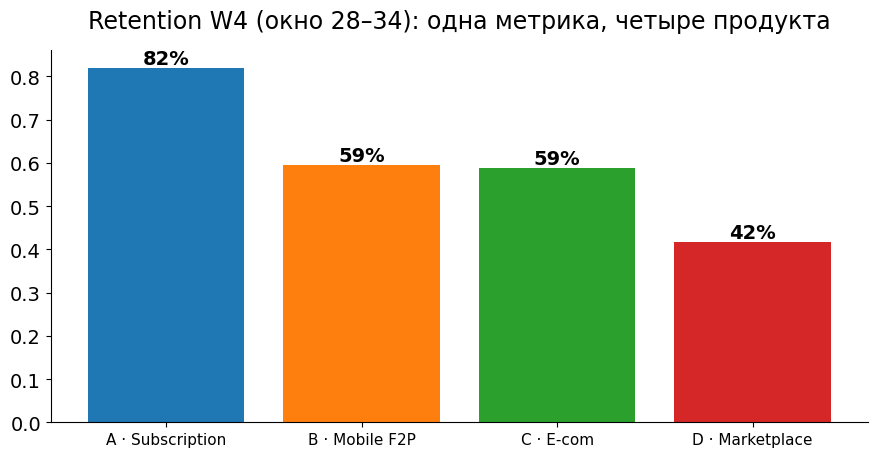

In [17]:
r = pd.Series({k: week4_retention(df) for k, df in logs.items()})

fig, ax = plt.subplots(figsize=(9, 4.8))
bars = ax.bar([f'{k} · {names[k]}' for k in r.index], r.values, color=[colors[k] for k in r.index])

ax.bar_label(bars, fmt='{:.0%}', fontsize=14, fontweight='bold')
ax.set_title('Retention W4 (окно 28–34): одна метрика, четыре продукта')
ax.tick_params(axis='x', labelsize=11)

plt.tight_layout()
plt.show()

### Финальный кейс: супер-апп

Вы — аналитик супер-аппа (такси + доставка еды + курьерская доставка, одна база пользователей).

Расставьте каждой метрике приоритет **P0–P3** по матрице из лекции: масштаб влияния (компания / вертикаль / фича) x этаж пирамиды. 


[**РЕШЕНИЕ**](https://docs.google.com/spreadsheets/d/1K4STTlApxbZsxXi1so5-nQ7oohEFjZ1oqCo2PsR3etM/edit?usp=sharing)